## User Notebook - Synthesis from Maps

The library supports **data synthesis** based on target maps/statistics. This notebook demonstrates how to use a **user-level wrapper** to generate syntheses that match the statistical properties of a target image.

Examples are provided to illustrate typical workflows.

**Note:**

- For **2D Kernel Data**: the **mean**, **variance**, **scattering coefficients**, and **power spectrum** are all optimized (for both periodic and non-periodic data, with or without NaN values).

- For **2D FFT Data**: the **mean**, **variance**, **scattering coefficients**, and **power spectrum** are all optimized (for periodic or non-periodic data; NaN values are not handled).

The **power spectrum** is currently not optimized when NaN values are present in either the target or the running map. This may be supported in the future for the kernel dataclass by implementing power spectrum estimation via convolution.

**Tip:**

During synthesis for generating a non-PBC image, some pixels located at the edges are not optimized because they do not contribute to the computation of scattering statistics. To obtain a non-PBC image that preserves the correct dimensions of the target, run the synthesis on an image that is twice as large and then crop the result.

In [ ]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
from pathlib import Path
import sys

from types import SimpleNamespace

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch, WaveletOperator2Dkernel_torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
from STL_main.Synthesis import synthesize_from_maps
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: cuda


In [3]:
def plot_target_vs_synthesis(target, synthesis, suptitle, titles=["Target", "Synthesis"]):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    t = target.cpu().numpy()
    u = synthesis.cpu().numpy()

    # Color scale limits of the target image, ignoring NaNs
    mean_t = np.nanmean(t)
    std_t = np.nanstd(t)

    vmin = mean_t - 3 * std_t
    vmax = mean_t + 3 * std_t

    im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[0].axis("off")
    axes[0].set_title(titles[0])

    im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[1].axis("off")
    axes[1].set_title(titles[1])

    fig.colorbar(im0, ax=axes, shrink=0.7)

    fig.suptitle(suptitle, fontsize=16)

    plt.show()

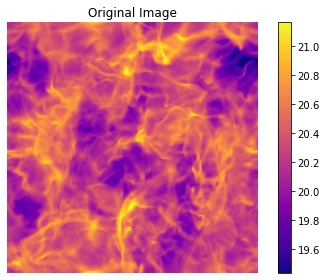

In [4]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Display original image
im_plot = plt.imshow(
    im[0, 0, :, :],
    cmap="plasma",
    vmin=np.nanmean(im) - 3 * np.nanstd(im),
    vmax=np.nanmean(im) + 3 * np.nanstd(im)
)
plt.title("Original Image")
plt.axis('off')
plt.colorbar(im_plot)
plt.tight_layout()
plt.show()

**The synthesis table below** summarizes all the syntheses performed in this certification notebook. It is not exhaustive: for example, it would be possible to perform FFT syntheses for many categories (except for syntheses where either the target, the running map, or both contain a mask).

| Category | Input image(s) | Output image(s) | Channel(s) | Method(s) |
|----------|---------------|-----------------|---------|--------|
| [One → One](#one_to_one) | 1 PBC image | 1 PBC image | Mono + Cross | Kernel + FFT |
| [One → One (Different Shape)](#one_to_one_diff_shape) | 1 PBC image | 1 PBC image | Mono | Kernel |
| [One → Many](#one_to_many) | 1 PBC image | N PBC images | Mono | Kernel |
| [Many → Many ($N \ne M$)](#many_to_many_n_neq_m) | N PBC image | M PBC images | Mono | Kernel |
| [Many → Many ($N = M$)](#many_to_many_n_eq_m) | N PBC image | M PBC images | Mono | Kernel |
| [PBC → Non PBC](#pbc_to_non_pbc) | 1 PBC image | 1 non-PBC image | Mono | Kernel |
| [Non PBC → PBC](#non_pbc_to_pbc) | 1 non-PBC image | 1 PBC image | Mono | Kernel |
| [Non PBC → Non PBC](#non_pbc_to_non_pbc) | 1 non-PBC image | 1 non-PBC image | Mono | Kernel |
| [NaNs → NaNs](#nans_to_nans) | 1 image with NaNs | 1 image with NaNs | Mono | Kernel |
| [NaNs → NaNs (Different Mask)](#nans_to_nans_diff_mask)| 1 image with NaNs  | 1 image with NaNs | Mono | Kernel |
| [Non NaNs → NaNs](#non_nans_to_nans) | 1 image without NaNs | 1 image with NaNs | Mono | Kernel |
| [NaNs → Non NaNs](#nans_to_non_nans) | 1 image with NaNs | 1 image without NaNs | Mono | Kernel |


<a id='one_to_one'></a>

#### 1. One → One 

##### 1.1 Kernel – Mono-Channel

In [ ]:
im_target = im[0, 0, :, :] # Target image (mono-channel)

# Instantiate kernel data class on the target image (should always specify pbc status of target dataclass)
data_target_kernel = STL_2D_Kernel_Torch(array=im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_kernel = synthesize_from_maps(
    data_target_kernel,
    pbc_running=True,
    nbatch=1
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3986 ST coefficients
[LBFGS] iter 10, loss = 6.892385e+03
[LBFGS] iter 20, loss = 3.189407e+01
[LBFGS] iter 30, loss = 1.091202e+01
[LBFGS] iter 40, loss = 3.446272e+00
[LBFGS] iter 50, loss = 1.626754e+00
[LBFGS] iter 60, loss = 8.614178e-01
[LBFGS] iter 70, loss = 5.912095e-01
[LBFGS] iter 80, loss = 4.294245e-01
[LBFGS] iter 90, loss = 3.312131e-01
[LBFGS] iter 100, loss = 2.815072e-01
[LBFGS] iter 110, loss = 2.405411e-01
110 iterations of synthesis.
Execution time: 17.672 s


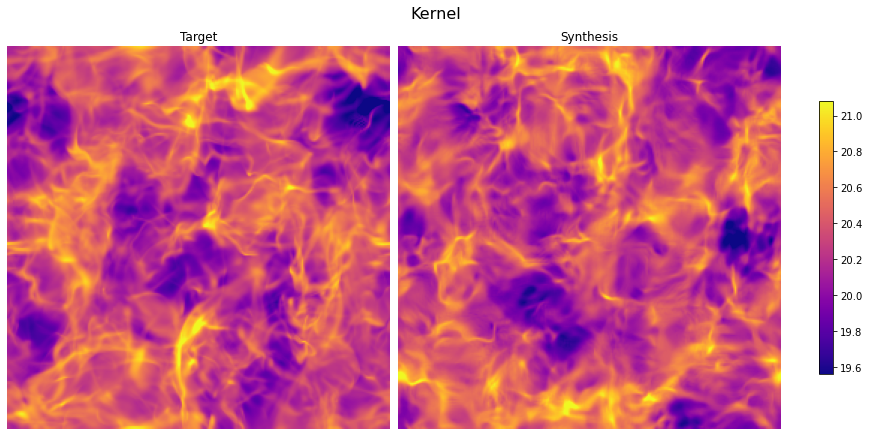

In [8]:
# Plot target vs synthesis
plot_target_vs_synthesis(data_target_kernel.array, u_kernel, suptitle = "Kernel", titles=["Target", "Synthesis"])

##### 1.2 FFT – Mono-Channel

Since the power spectrum is systematically included in the synthesis optimization, it is necessary in mono-channel FFT to increase the number of iterations, as the power spectrum dominates the scattering coefficients in the loss.

In [ ]:
im_target = im[0, 0, :, :] # Target image (mono-channel)

# Instantiate FFT data class on the target image
data_target_fft = STL_2D_FFT_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_fft = synthesize_from_maps(
    data_target_fft,
    nbatch=1,
    pbc_running=True
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3986 ST coefficients
[LBFGS] iter 10, loss = 6.623537e+03
[LBFGS] iter 20, loss = 2.367661e+01
[LBFGS] iter 30, loss = 3.178361e+00
[LBFGS] iter 40, loss = 5.636598e-01
[LBFGS] iter 50, loss = 2.582128e-01
[LBFGS] iter 60, loss = 1.684499e-01
[LBFGS] iter 70, loss = 1.161277e-01
[LBFGS] iter 80, loss = 9.056256e-02
[LBFGS] iter 90, loss = 7.619082e-02
[LBFGS] iter 100, loss = 4.556049e-02
108 iterations of synthesis.
Execution time: 9.898 s


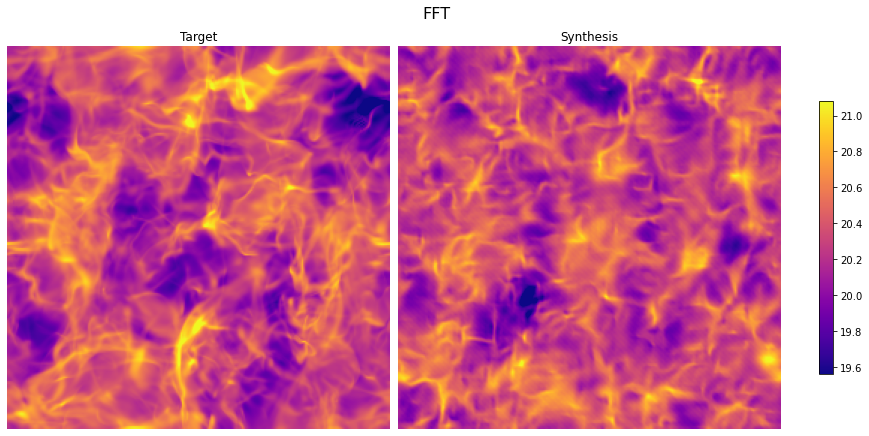

In [10]:
plot_target_vs_synthesis(data_target_fft.array, u_fft, suptitle = "FFT", titles=["Target", "Synthesis"])

##### 1.3 Kernel – Multi-Channel

In [12]:
# Make a multi-channel target image
im_target = np.stack([im[0, 0, :, :], (im[0 ,0, :, :]-im[0, 0, :, :].mean(keepdims=True))**2])
im_target -= im_target.mean(axis=(1,2), keepdims=True)

# Instantiate kernel data class on the multi-channel target image
data_target_kernel_multi_channel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)
u_kernel_multi_channel = synthesize_from_maps(
    data_target_kernel_multi_channel,
    pbc_running=True,
    nbatch=1,
    compute_cross_matrix=compute_cross_matrix
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 2, 256, 256)
Synthesis on 15876 ST coefficients
[LBFGS] iter 10, loss = 1.340711e+04
[LBFGS] iter 20, loss = 1.198997e+02
[LBFGS] iter 30, loss = 3.273343e+01
[LBFGS] iter 40, loss = 9.738984e+00
[LBFGS] iter 50, loss = 5.147368e+00
[LBFGS] iter 60, loss = 3.385684e+00
[LBFGS] iter 70, loss = 2.572010e+00
[LBFGS] iter 80, loss = 2.174822e+00
[LBFGS] iter 90, loss = 1.926011e+00
[LBFGS] iter 100, loss = 1.710570e+00
109 iterations of synthesis.
Execution time: 26.766 s


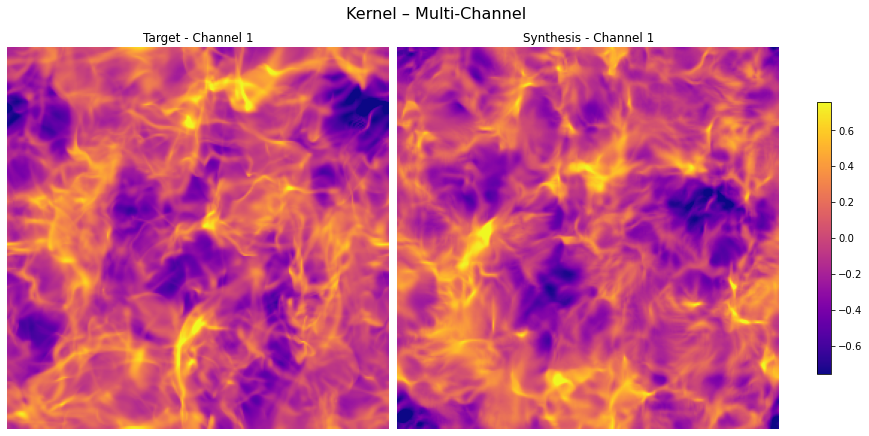

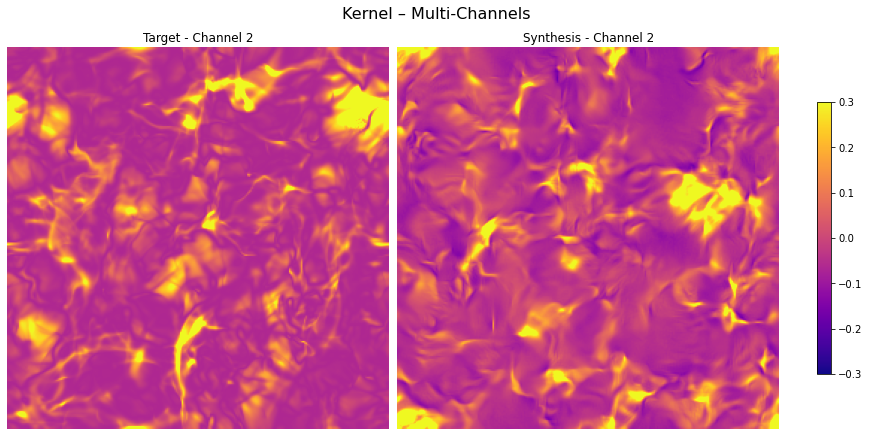

In [ ]:
plot_target_vs_synthesis(data_target_kernel_multi_channel.array[0], u_kernel_multi_channel[0], suptitle = "Kernel – Multi-Channel", titles=["Target - Channel 1", "Synthesis - Channel 1"])
plot_target_vs_synthesis(data_target_kernel_multi_channel.array[1], u_kernel_multi_channel[1], suptitle = "Kernel – Multi-Channel", titles=["Target - Channel 2", "Synthesis - Channel 2"])

##### 1.4 FFT – Multi-Channel

In [15]:
# Make a multi-channel target image
im_target = np.stack([im[0, 0, :, :], (im[0 ,0, :, :]-im[0, 0, :, :].mean(keepdims=True))**2])
im_target -= im_target.mean(axis=(1,2), keepdims=True)

# Instantiate FFT data class on the multi-channel target image
data_target_fft_multi_channel = STL_2D_FFT_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)
u_fft_multi_channel = synthesize_from_maps(
    data_target_fft_multi_channel,
    pbc_running=True,
    nbatch=1,
    compute_cross_matrix=compute_cross_matrix
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 2, 256, 256)
Synthesis on 15876 ST coefficients
[LBFGS] iter 10, loss = 1.287008e+04
[LBFGS] iter 20, loss = 4.984007e+01
[LBFGS] iter 30, loss = 1.245868e+01
[LBFGS] iter 40, loss = 3.393858e+00
[LBFGS] iter 50, loss = 1.529519e+00
[LBFGS] iter 60, loss = 8.601757e-01
[LBFGS] iter 70, loss = 5.940558e-01
[LBFGS] iter 80, loss = 4.377072e-01
[LBFGS] iter 90, loss = 3.227050e-01
[LBFGS] iter 100, loss = 2.473938e-01
[LBFGS] iter 110, loss = 1.957341e-01
111 iterations of synthesis.
Execution time: 25.798 s


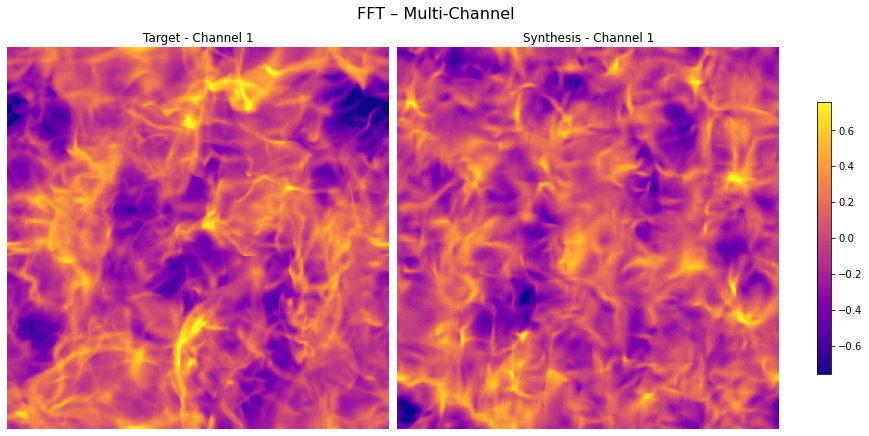

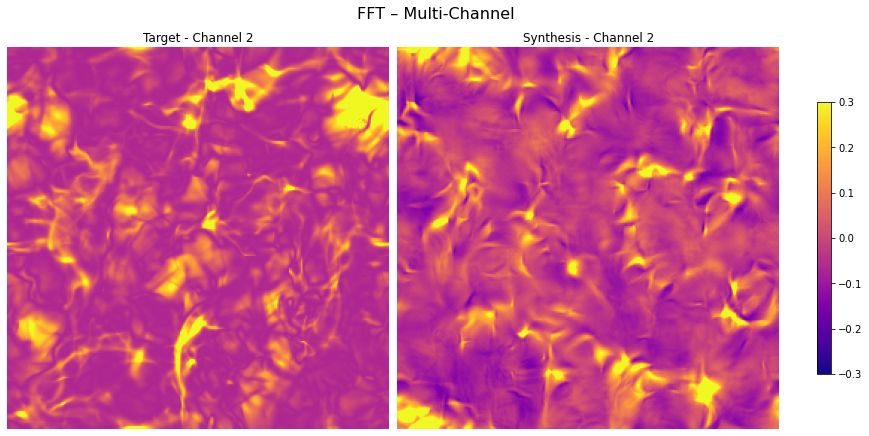

In [16]:
plot_target_vs_synthesis(data_target_fft_multi_channels.array[0], u_fft_multi_channels[0], suptitle = "FFT – Multi-Channel", titles=["Target - Channel 1", "Synthesis - Channel 1"])
plot_target_vs_synthesis(data_target_fft_multi_channels.array[1], u_fft_multi_channels[1], suptitle = "FFT – Multi-Channel", titles=["Target - Channel 2", "Synthesis - Channel 2"])

<a id='one_to_one_diff_shape'></a>

#### One → One (different shape)

In [17]:
im_target = im[0, 0, :, :] # Target image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_kernel_128 = synthesize_from_maps(
    data_target_kernel,
    pbc_running=True,
    nbatch=1,
    running_shape=(128, 128)
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 128, 128)
Synthesis on 2530 ST coefficients
[LBFGS] iter 10, loss = 1.053576e+03
[LBFGS] iter 20, loss = 1.188269e+01
[LBFGS] iter 30, loss = 2.034339e+00
[LBFGS] iter 40, loss = 9.154164e-01
[LBFGS] iter 50, loss = 5.717389e-01
[LBFGS] iter 60, loss = 4.579586e-01
[LBFGS] iter 70, loss = 3.803055e-01
[LBFGS] iter 80, loss = 3.386586e-01
[LBFGS] iter 90, loss = 2.928288e-01
[LBFGS] iter 100, loss = 2.627973e-01
107 iterations of synthesis.
Execution time: 12.279 s


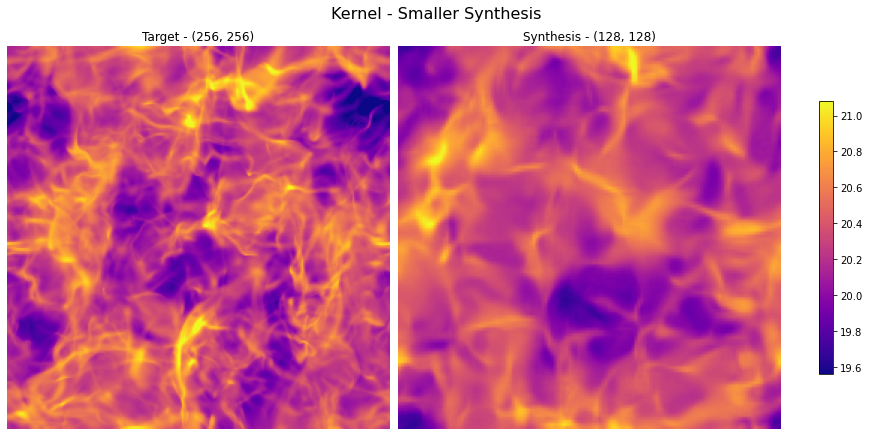

In [18]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_128, suptitle = "Kernel - Smaller Synthesis", titles=["Target - (256, 256)", "Synthesis - (128, 128)"])

In [23]:
im_target = im[0, 0, :, :] # Target image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_kernel_512 = synthesize_from_maps(
    data_target_kernel,
    pbc_running=True,
    nbatch=1,
    running_shape=(512, 512)
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 512, 512)
Synthesis on 3986 ST coefficients
[LBFGS] iter 10, loss = 8.871584e+03
[LBFGS] iter 20, loss = 3.329502e+01
[LBFGS] iter 30, loss = 1.185475e+01
[LBFGS] iter 40, loss = 2.235185e+00
[LBFGS] iter 50, loss = 8.517537e-01
[LBFGS] iter 60, loss = 4.264248e-01
[LBFGS] iter 70, loss = 2.627878e-01
[LBFGS] iter 80, loss = 1.888821e-01
[LBFGS] iter 90, loss = 1.364459e-01
[LBFGS] iter 100, loss = 1.097556e-01
109 iterations of synthesis.
Execution time: 20.756 s


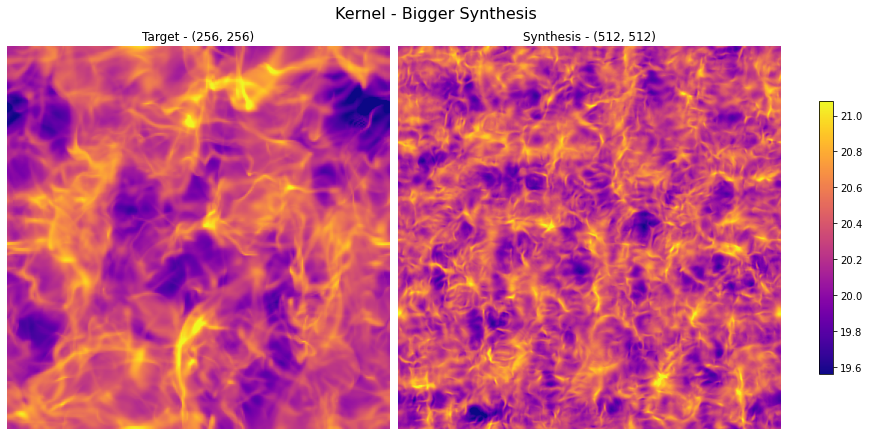

In [22]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_512, suptitle = "Kernel - Bigger Synthesis", titles=["Target - (256, 256)", "Synthesis - (512, 512)"])

<a id='one_to_many'></a>

#### One → Many

In [7]:
im_target = im[0, 0, :, :] # Target image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
nbatch = 4
u_kernel_many_maps = synthesize_from_maps(
    data_target_kernel,
    nbatch=nbatch,
    pbc_running=True
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (4, 1, 256, 256)
Synthesis on 3986 ST coefficients
[LBFGS] iter 10, loss = 8.332590e+03
[LBFGS] iter 20, loss = 3.299758e+01
[LBFGS] iter 30, loss = 1.464123e+01
[LBFGS] iter 40, loss = 2.689097e+00
[LBFGS] iter 50, loss = 8.216426e-01
[LBFGS] iter 60, loss = 4.112447e-01
[LBFGS] iter 70, loss = 2.798896e-01
[LBFGS] iter 80, loss = 2.009115e-01
[LBFGS] iter 90, loss = 1.515299e-01
[LBFGS] iter 100, loss = 1.175751e-01
[LBFGS] iter 110, loss = 9.801338e-02
111 iterations of synthesis.
Execution time: 20.348 s


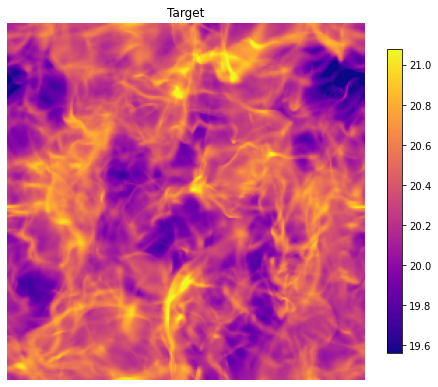

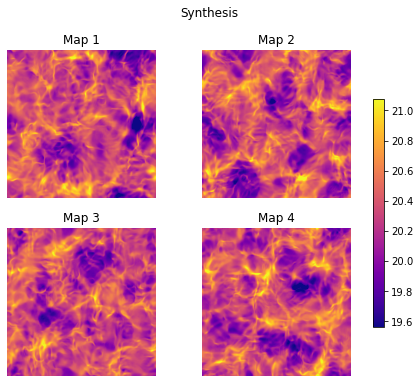

In [9]:
to_numpy = lambda x: x.detach().cpu().numpy()

t = to_numpy(data_target_kernel.array)
u_list = [to_numpy(u) for u in u_kernel_many_maps[:4]]

mean_t = np.nanmean(t)
std_t = np.nanstd(t)

vmin = mean_t - 3 * std_t
vmax = mean_t + 3 * std_t

# --- Target ---
fig_target, ax = plt.subplots(figsize=(8, 8))
im0 = ax.imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
ax.axis("off")
ax.set_title("Target")
fig_target.colorbar(im0, ax=ax, shrink=0.7)

# --- Synthesis ---
fig_synthesis, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_synthesis.suptitle("Synthesis")

for i, (ax, u) in enumerate(zip(axes.flat, u_list), start=1):
    im0 = ax.imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Map {i}")

fig_synthesis.colorbar(im0, ax=axes.ravel().tolist(), shrink=0.7)

plt.show()

<a id='many_to_many_n_neq_m'></a>

#### Many -> Many ($N \ne M$)

In this scenario, the `mean_field` argument of the `synthesize_from_maps` synthesis wrapper is left at its default value. This means that when optimizing the statistics, they are averaged over the **batch dimension**, rather than computed **map by map**.

In [10]:
im_target = im[:4, 0:1, :, :] # Target image with many maps

# Instantiate kernel data class on the target images
data_target_kernel_many_maps = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
nbatch = 6
u_kernel_many_maps = synthesize_from_maps(
    data_target_kernel_many_maps,
    nbatch=nbatch,
    pbc_running=True,
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (6, 1, 256, 256)
Synthesis on 3986 ST coefficients
[LBFGS] iter 10, loss = 2.124673e+04
[LBFGS] iter 20, loss = 3.713129e+01
[LBFGS] iter 30, loss = 1.417141e+01
[LBFGS] iter 40, loss = 4.481472e+00
[LBFGS] iter 50, loss = 6.876723e-01
[LBFGS] iter 60, loss = 3.029230e-01
[LBFGS] iter 70, loss = 1.745833e-01
[LBFGS] iter 80, loss = 1.043043e-01
[LBFGS] iter 90, loss = 7.415564e-02
[LBFGS] iter 100, loss = 5.126262e-02
[LBFGS] iter 110, loss = 4.056706e-02
113 iterations of synthesis.
Execution time: 22.803 s


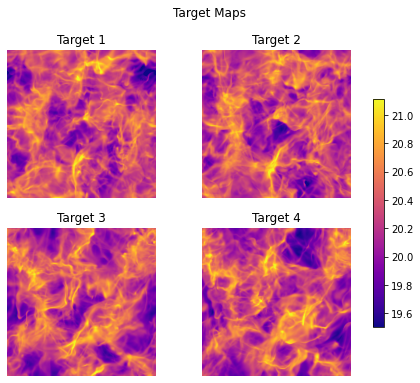

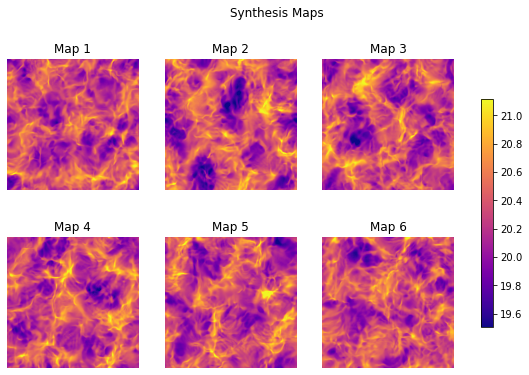

In [13]:
to_numpy = lambda x: x.detach().cpu().numpy()

t_list = [to_numpy(t) for t in data_target_kernel_many_maps.array[:4, 0]]  # 4 maps  
u_list = [to_numpy(u) for u in u_kernel_many_maps[:6, 0]]  # 6 maps

# Flatten target arrays to compute global vmin/vmax
mean_t = np.nanmean(t_list)
std_t = np.nanstd(t_list)

vmin = mean_t - 3 * std_t
vmax = mean_t + 3 * std_t

# --- Plot Target Maps ---
fig_target, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_target.suptitle("Target Maps")

for ax, t, i in zip(axes.flatten(), t_list, range(4)):
    im0 = ax.imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Target {i+1}")

fig_target.colorbar(im0, ax=axes, shrink=0.7)
plt.suptitle("Target Maps")

# --- Plot Synthesis Maps ---
fig_synth, axes = plt.subplots(2, 3, figsize=(10, 6))
fig_synth.suptitle("Synthesis Maps")

for ax, u, i in zip(axes.flatten(), u_list, range(6)):
    im0 = ax.imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Map {i+1}")

fig_synth.colorbar(im0, ax=axes, shrink=0.7)

plt.show()

<a id='many_to_many_n_eq_m'></a>

#### Many -> Many ($N = M$)

In this scenario, the `mean_field` argument of the `synthesize_from_maps` synthesis wrapper is set to `False`. This means that the statistics are optimized **map by map**, so it is necessary to have the **same batch size** for both the target and the running data.

In [14]:
im_target = im[:4, 0:1, :, :] # Target image with many maps

# Instantiate kernel data class on the target image
data_target_kernel_many_maps = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
nbatch = 4
u_kernel_many_maps = synthesize_from_maps(
    data_target_kernel_many_maps,
    nbatch=nbatch,
    pbc_running=True,
    mean_field=False
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (4, 1, 256, 256)
Synthesis on 15944 ST coefficients
[LBFGS] iter 10, loss = 4.267633e+04
[LBFGS] iter 20, loss = 1.365385e+02
[LBFGS] iter 30, loss = 7.395271e+01
[LBFGS] iter 40, loss = 3.411360e+01
[LBFGS] iter 50, loss = 1.486757e+01
[LBFGS] iter 60, loss = 7.712630e+00
[LBFGS] iter 70, loss = 5.207787e+00
[LBFGS] iter 80, loss = 3.672976e+00
[LBFGS] iter 90, loss = 2.775342e+00
[LBFGS] iter 100, loss = 2.196776e+00
[LBFGS] iter 110, loss = 1.846760e+00
110 iterations of synthesis.
Execution time: 18.730 s


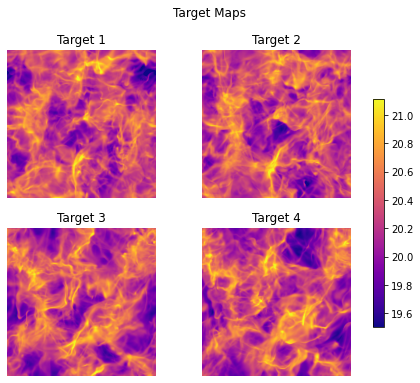

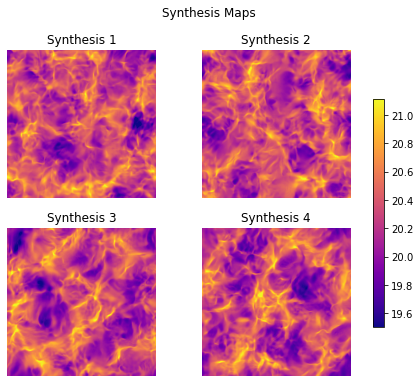

In [15]:
to_numpy = lambda x: x.detach().cpu().numpy()

t_list = [to_numpy(t) for t in data_target_kernel_many_maps.array[:4, 0]]  # 4 maps  
u_list = [to_numpy(u) for u in u_kernel_many_maps[:4, 0]]  # 4 maps

# Flatten target arrays to compute global vmin/vmax
mean_t = np.nanmean(t_list)
std_t = np.nanstd(t_list)

vmin = mean_t - 3 * std_t
vmax = mean_t + 3 * std_t

# --- Plot Target Maps ---
fig_target, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_target.suptitle("Target Maps")

for ax, t, i in zip(axes.flatten(), t_list, range(4)):
    im0 = ax.imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Target {i+1}")

fig_target.colorbar(im0, ax=axes, shrink=0.7)
plt.suptitle("Target Maps")

# --- Plot Synthesis Maps ---
fig_synth, axes = plt.subplots(2, 2, figsize=(8, 6))
fig_synth.suptitle("Synthesis Maps")

for ax, u, i in zip(axes.flatten(), u_list, range(4)):
    im0 = ax.imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    ax.set_title(f"Synthesis {i+1}")

fig_synth.colorbar(im0, ax=axes, shrink=0.7)

plt.show()

<a id='pbc_to_non_pbc'></a>

#### PBC → Non PBC

In this section, we attempt to synthesize a **non-periodic image** from a **periodic target**. Two remarks:

- One dyadic scale is removed from the underlying ST operators of the synthesis to achieve better results.  
- The **crop method** used for estimating statistics with a non-PBC map is the default (`fully_flexible`). To use another crop method, the user-friendly wrapper does not allow it; you need to specify the crop method at a **mid-level synthesis function**.

In [16]:
im_target = im[0, 0, :, :] # Target image (PBC)

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_kernel_no_pbc = synthesize_from_maps(
    data_target_kernel,
    nbatch=1,
    pbc_running=False,
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 2538 ST coefficients
[LBFGS] iter 10, loss = 6.614217e+03
[LBFGS] iter 20, loss = 2.143696e+01
[LBFGS] iter 30, loss = 1.007023e+01
[LBFGS] iter 40, loss = 2.072143e+00
[LBFGS] iter 50, loss = 7.647625e-01
[LBFGS] iter 60, loss = 5.413319e-01
[LBFGS] iter 70, loss = 4.384134e-01
[LBFGS] iter 80, loss = 3.526831e-01
[LBFGS] iter 90, loss = 2.941720e-01
[LBFGS] iter 100, loss = 2.520320e-01
108 iterations of synthesis.
Execution time: 9.980 s


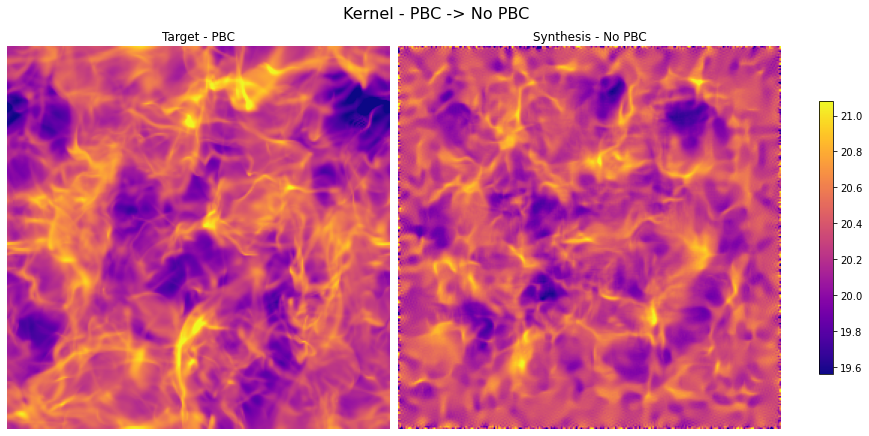

In [17]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_no_pbc, suptitle = "Kernel - PBC -> No PBC", titles=["Target - PBC", "Synthesis - No PBC"])

<a id='non_pbc_to_pbc'></a>

#### Non PBC → PBC

In [18]:
im_target = im[0, 0, :128, :128] # Target image (no PBC)

# Instantiate kernel data class on the target image
data_target_kernel_no_pbc = STL_2D_Kernel_Torch(im_target, pbc=False)

# Call user-level synthesis-from-maps wrapper
u_kernel_pbc = synthesize_from_maps(
    data_target_kernel_no_pbc,
    nbatch=1,
    pbc_running=True,
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 128, 128)
Synthesis on 1482 ST coefficients
[LBFGS] iter 10, loss = 2.144495e+04
[LBFGS] iter 20, loss = 2.003914e+01
[LBFGS] iter 30, loss = 1.696133e+01
[LBFGS] iter 40, loss = 2.443695e+00
[LBFGS] iter 50, loss = 1.336022e+00
[LBFGS] iter 60, loss = 1.012783e+00
[LBFGS] iter 70, loss = 8.363791e-01
[LBFGS] iter 80, loss = 7.448217e-01
[LBFGS] iter 90, loss = 6.654429e-01
[LBFGS] iter 100, loss = 5.709047e-01
[LBFGS] iter 110, loss = 5.207079e-01
116 iterations of synthesis.
Execution time: 9.196 s


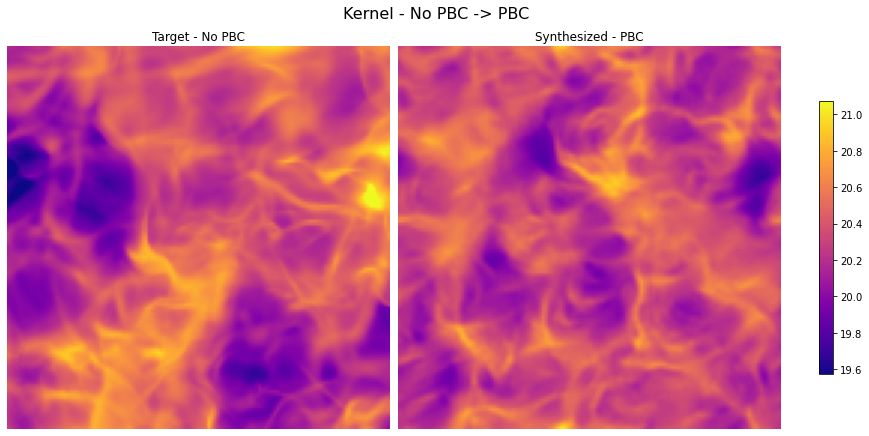

In [19]:
plot_target_vs_synthesis(data_target_kernel_no_pbc.array, u_kernel_pbc, suptitle = "Kernel - No PBC -> PBC", titles=["Target - No PBC", "Synthesized - PBC"])

<a id='non_pbc_to_non_pbc'></a>

#### Non PBC → Non PBC

In [20]:
im_target = im[0, 0, :128, :128] # Target image (no PBC)

# Instantiate kernel data class on the target image
data_target_kernel_no_pbc = STL_2D_Kernel_Torch(im_target, pbc=False)

# Call user-level synthesis-from-maps wrapper
u_kernel_no_pbc = synthesize_from_maps(
    data_target_kernel_no_pbc,
    nbatch=1,
    pbc_running=False,
)

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 128, 128)
Synthesis on 1482 ST coefficients
[LBFGS] iter 10, loss = 2.099691e+04
[LBFGS] iter 20, loss = 2.421284e+01
[LBFGS] iter 30, loss = 1.107009e+01
[LBFGS] iter 40, loss = 6.643667e+00
[LBFGS] iter 50, loss = 2.960228e+00
[LBFGS] iter 60, loss = 1.682919e+00
[LBFGS] iter 70, loss = 1.334058e+00
[LBFGS] iter 80, loss = 1.047477e+00
[LBFGS] iter 90, loss = 8.766812e-01
[LBFGS] iter 100, loss = 7.353196e-01
[LBFGS] iter 110, loss = 6.276769e-01
113 iterations of synthesis.
Execution time: 7.732 s


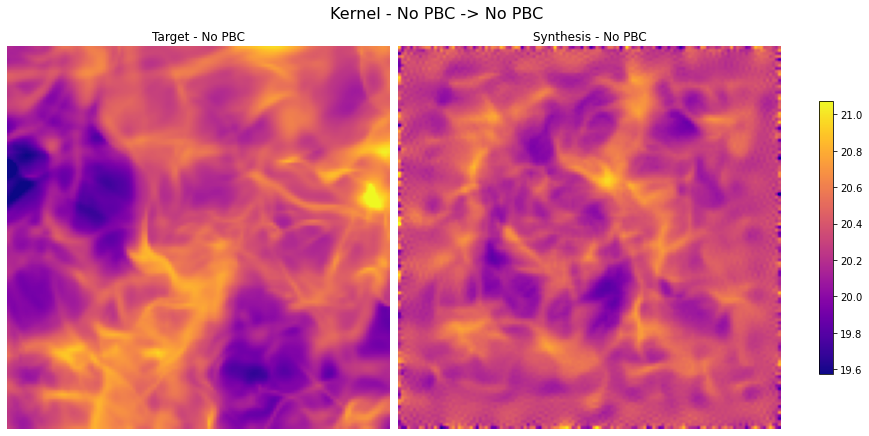

In [21]:
plot_target_vs_synthesis(data_target_kernel_no_pbc.array, u_kernel_no_pbc, suptitle = "Kernel - No PBC -> No PBC", titles=["Target - No PBC", "Synthesis - No PBC"])

<a id='nans_to_nans'></a>

#### NaNs → NaNs

For syntheses whose running maps include a mask, it is preferable to increase the number of optimization iterations, as pixels near NaNs generally take longer to converge.

**Notes:** Optimization parameters can be overridden by the user in the `synthesize_from_maps` wrapper, for example the `max_iter` parameter for syntheses whose running maps include a mask.

In [22]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Instantiate kernel data class on NaN target image
data_target_kernel_nan = STL_2D_Kernel_Torch(array=im_target_nan, pbc=True)

# Call user-level synthesis-from-maps wrapper
max_iter = 70 # overwrite default max_iter
u_kernel_nan = synthesize_from_maps(
    data_target_kernel_nan,
    nbatch=1,
    pbc_running=True,
    max_iter=max_iter
)

⚠️ Warning: NaN detected in target and/or running data.
Power spectrum optimization is disabled because its computation is not yet implemented for NaN values in any dataclass. 

Running synthesis on device: cuda:0 dtype: torch.float64
NaN detected in the target, the synthesis takes it into account
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.969525e+02
[LBFGS] iter 20, loss = 1.206750e+01
[LBFGS] iter 30, loss = 1.628439e+00
[LBFGS] iter 40, loss = 7.176698e-01
[LBFGS] iter 50, loss = 4.504022e-01
[LBFGS] iter 60, loss = 3.408215e-01
[LBFGS] iter 70, loss = 2.951579e-01
78 iterations of synthesis.
Execution time: 11.458 s
NaN detected in the optimized field, cannot apply Nyquist filter


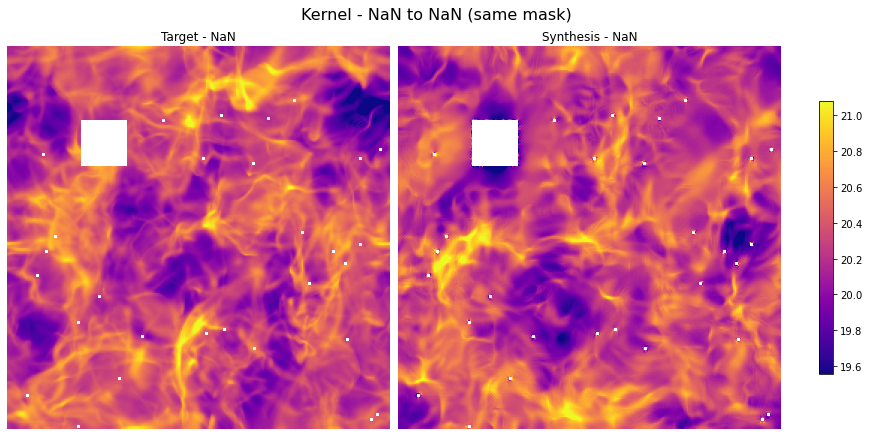

In [23]:
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel_nan, suptitle = "Kernel - NaN to NaN (same mask)", titles=["Target - NaN", "Synthesis - NaN"])

<a id='nans_to_nans_diff_mask'></a>

#### NaNs → NaNs (Different Mask)

In [24]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Specifiy an array running mask different from the NaN mask of the target image
running_mask = np.zeros_like(im[0, 0, :, :])
running_mask[(np.random.rand(30)*running_mask.shape[0]).astype('int'),
    (np.random.rand(30)*running_mask.shape[0]).astype('int')] = np.nan
running_mask[150:175,150:175] = np.nan

# Instantiate kernel data class
data_target_kernel_nan = STL_2D_Kernel_Torch(im_target_nan, pbc=True)

# Call user-friendly synthesis wrapper
max_iter = 70 # overwrite default max_iter
u_kernel_nan_new_mask = synthesize_from_maps(
    data_target_kernel_nan,
    pbc_running=True,
    nbatch=1,
    running_mask=running_mask,
    max_iter=max_iter
)

⚠️ Warning: NaN detected in target and/or running data.
Power spectrum optimization is disabled because its computation is not yet implemented for NaN values in any dataclass. 

Running synthesis on device: cuda:0 dtype: torch.float64
NaN detected in the target, the synthesis takes it into account
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.972684e+02
[LBFGS] iter 20, loss = 1.185849e+01
[LBFGS] iter 30, loss = 1.682789e+00
[LBFGS] iter 40, loss = 7.210787e-01
[LBFGS] iter 50, loss = 4.198613e-01
[LBFGS] iter 60, loss = 3.084296e-01
[LBFGS] iter 70, loss = 2.581565e-01
[LBFGS] iter 80, loss = 2.260053e-01
80 iterations of synthesis.
Execution time: 13.210 s
NaN detected in the optimized field, cannot apply Nyquist filter


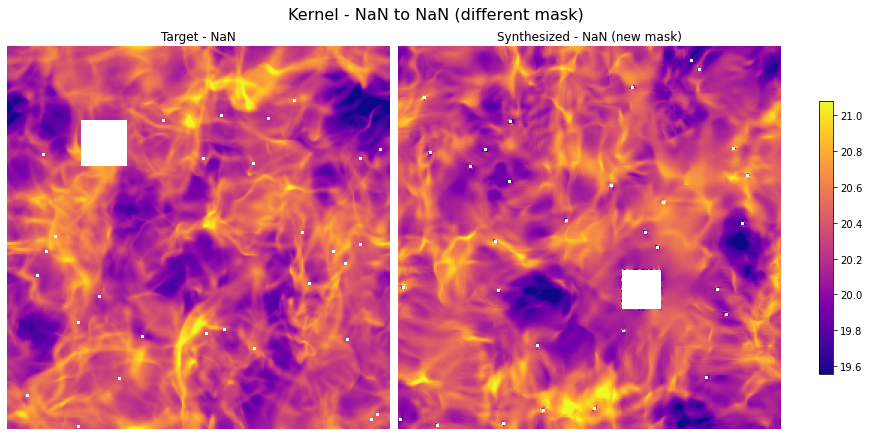

In [25]:
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel_nan_new_mask, suptitle = "Kernel - NaN to NaN (different mask)", titles=["Target - NaN", "Synthesized - NaN (new mask)"])

<a id='non_nans_to_nans'></a>

#### Non NaNs → NaNs

In [ ]:
im_target = im[0, 0, :, :]

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block to a NaN mask 
seed = 26
np.random.seed(seed)

# Instantiate kernel data class
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Specifiy an array running mask
running_mask = np.zeros_like(im[0, 0, :, :])
running_mask[(np.random.rand(30)*running_mask.shape[0]).astype('int'),
    (np.random.rand(30)*running_mask.shape[0]).astype('int')] = np.nan
running_mask[50:80,50:80] = np.nan

# Call user-level synthesis-from-maps wrapper
max_iter = 70 # overwrite default max_iter
u_kernel_nan = synthesize_from_maps(
    data_target_kernel,
    nbatch=1,
    pbc_running=True,
    running_mask=running_mask,
    max_iter=max_iter
)

⚠️ Warning: NaN detected in target and/or running data.
Power spectrum optimization is disabled because its computation is not yet implemented for NaN values in any dataclass. 

Running synthesis on device: cuda:0 dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
NaN detected in the running synthesis mask, the synthesis takes it into account
[LBFGS] iter 10, loss = 1.979691e+02
[LBFGS] iter 20, loss = 1.187365e+01
[LBFGS] iter 30, loss = 1.551627e+00
[LBFGS] iter 40, loss = 6.254052e-01
[LBFGS] iter 50, loss = 3.897363e-01
[LBFGS] iter 60, loss = 2.810128e-01
[LBFGS] iter 70, loss = 2.353376e-01
78 iterations of synthesis.
Execution time: 12.869 s
NaN detected in the optimized field, cannot apply Nyquist filter


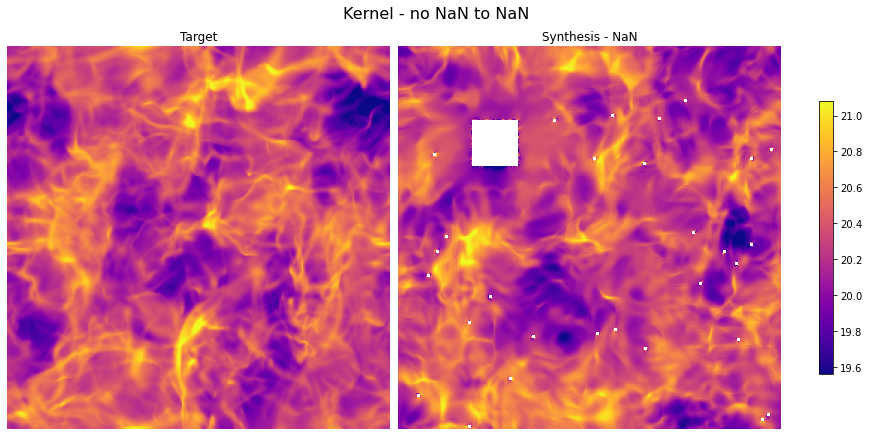

In [28]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel_nan, suptitle = "Kernel - no NaN to NaN", titles=["Target", "Synthesis - NaN"])

<a id='nans_to_non_nans'></a>

#### NaNs → Non NaNs

In [29]:
seed = 26
np.random.seed(seed)

im_target_nan = im[0, 0, :, :].copy()

# Add ~30 scattered NaN pixels and a 30x30 NaN pixel block 
im_target_nan[(np.random.rand(30)*im_target_nan.shape[0]).astype('int'),
    (np.random.rand(30)*im_target_nan.shape[0]).astype('int')] = np.nan
im_target_nan[50:80,50:80] = np.nan

# Instantiate kernel data class
data_target_kernel_nan = STL_2D_Kernel_Torch(im_target_nan, pbc=True)

# Specifiy an empty running mask 
running_mask = np.zeros_like(im[0, 0, :, :])

# Call user-friendly synthesis wrapper
u_kernel_no_nan = synthesize_from_maps(
    data_target_kernel_nan,
    pbc_running=True,
    nbatch=1,
    running_mask=running_mask
)

⚠️ Warning: NaN detected in target and/or running data.
Power spectrum optimization is disabled because its computation is not yet implemented for NaN values in any dataclass. 

Running synthesis on device: cuda:0 dtype: torch.float64
NaN detected in the target, the synthesis takes it into account
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] iter 10, loss = 1.978068e+02
[LBFGS] iter 20, loss = 1.267108e+01
[LBFGS] iter 30, loss = 1.728899e+00
[LBFGS] iter 40, loss = 7.500061e-01
[LBFGS] iter 50, loss = 4.283291e-01
[LBFGS] iter 60, loss = 3.222106e-01
[LBFGS] iter 70, loss = 2.549388e-01
[LBFGS] iter 80, loss = 2.179801e-01
[LBFGS] iter 90, loss = 1.898946e-01
[LBFGS] iter 100, loss = 1.727409e-01
[LBFGS] iter 110, loss = 1.615694e-01
110 iterations of synthesis.
Execution time: 16.075 s


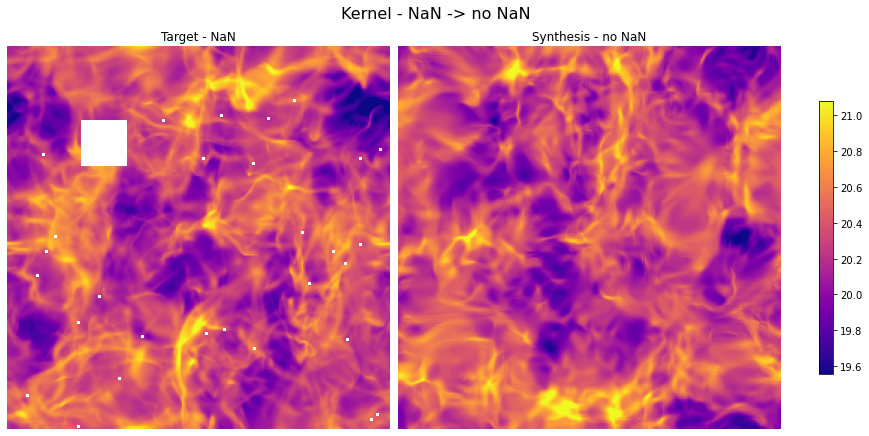

In [31]:
plot_target_vs_synthesis(data_target_kernel_nan.array, u_kernel_no_nan, suptitle = "Kernel - NaN -> no NaN", titles=["Target - NaN", "Synthesis - no NaN"])